In [34]:
import pandas as pd
import requests
import json
import datetime
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
is_spatial = pd.read_excel('interim/is_spatial_20260125_edits.xlsx')

In [19]:
is_spatial.is_spatial_count.eq(5).sum()

628

In [29]:
is_spatial[is_spatial.is_spatial_count.ge(1) & is_spatial.human_check.eq(1)]

,query_id,query_text,is_spatial,is_spatial_count,human_check,note
20,105273,cost of living in palo alto,"['true', 'true', 'true', 'false', 'true']",4,1.0,NaN
24,980353,where is columbia river?,"['true', 'true', 'true', 'true', 'true']",5,1.0,NaN
36,209211,how big is london in miles,"['true', 'true', 'true', 'true', 'true']",5,1.0,NaN
71,45889,average temperatures in reykjavik in May,"['false', 'false', 'false', 'false', 'true']",1,1.0,NaN
76,545569,weather in plains montana month,"['true', 'true', 'true', 'true', 'true']",5,1.0,NaN
...,...,...,...,...,...,...
11844,611868,what county is reynolds nd,"['true', 'true', 'true', 'true', 'true']",5,1.0,NaN
11854,813149,what is the county for kermit tx,"['true', 'true', 'true', 'true', 'true']",5,1.0,NaN
11898,1167689,weather in north dakota in may,"['true', 'true', 'true', 'true', 'true']",5,1.0,NaN
11963,1163879,"what county is harvard, ma in/","['true', 'true', 'true', 'true', 'true']",5,1.0,NaN


In [28]:
is_spatial[is_spatial.is_spatial_count.eq(0) & is_spatial.human_check.eq(1)]

,query_id,query_text,is_spatial,is_spatial_count,human_check,note
43,313287,how much does broccoli cost in canada,"['false', 'false', 'false', 'false', 'false']",0,1.0,price in location
324,1180955,how is the weather in japan in march,"['false', 'false', 'false', 'false', 'false']",0,1.0,weather factoid / unclear
348,53113,biggest gmc dealer omaha,"['false', 'false', 'false', 'false', 'false']",0,1.0,searching for a particular retailer
508,904773,what time in denmark,"['false', 'false', 'false', 'false', 'false']",0,1.0,timezone?
592,327500,how much should i pay for a custom made suit i...,"['false', 'false', 'false', 'false', 'false']",0,1.0,price in a place?
675,905467,what time us un nyc,"['false', 'false', 'false', 'false', 'false']",0,1.0,timezone?
778,1145697,what time is it in gruver tx,"['false', 'false', 'false', 'false', 'false']",0,1.0,timezone


In [14]:
majority_voting_data = (
    is_spatial
    .query('is_spatial_count > 0')
    .groupby('is_spatial_count')
    .agg({'human_check': ['count', 'mean']})
    ['human_check']
)

majority_voting_data['percent_true'] = majority_voting_data['mean'] * 100

majority_voting_data

,count,mean,percent_true
is_spatial_count,,,
1,43,0.697674,69.767442
2,16,0.937500,93.750000
3,20,0.850000,85.000000
4,36,0.833333,83.333333
5,628,0.985669,98.566879


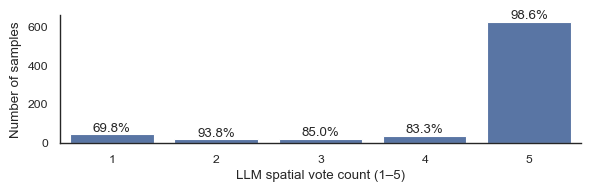

In [12]:
# Minimal style
sns.set_theme(style='white', context='paper')

fig, ax = plt.subplots(figsize=(6, 2))

# Bar plot
sns.barplot(
    data=majority_voting_data,
    x='is_spatial_count',
    y='count',
    ax=ax
)

# Percentage annotations
for i, row in majority_voting_data.iterrows():
    ax.text(
        i-1,
        row['count'],
        f"{row['percent_true']:.1f}%",
        ha='center',
        va='bottom'
    )

# Labels (no title – use caption in paper)
ax.set_xlabel('LLM spatial vote count (1–5)')
ax.set_ylabel('Number of samples')

sns.despine()
plt.tight_layout()

# For publication export:
plt.savefig('figures/spatial-1-5.pdf', bbox_inches='tight')
plt.show()

In [31]:
def md_clusters_to_latex_rows(md_path: str, top_k_terms: int = 5) -> str:
    import re
    from pathlib import Path

    def esc(s: str) -> str:
        # Minimal LaTeX escaping for table cells
        repl = {
            '\\': r'\textbackslash{}',
            '&': r'\&',
            '%': r'\%',
            '$': r'\$',
            '#': r'\#',
            '_': r'\_',
            '{': r'\{',
            '}': r'\}',
            '~': r'\textasciitilde{}',
            '^': r'\textasciicircum{}',
        }
        return ''.join(repl.get(ch, ch) for ch in s)

    md = Path(md_path).read_text(encoding='utf-8')

    blocks = re.split(r'(?m)^\s*---\s*$', md)
    header_re = re.compile(r'(?m)^\s*##\s*Cluster\s+(-?\d+)\s*\(([\d,]+)\s+samples\)\s*$')
    rep_re = re.compile(r'(?m)^\s*\*\*Representative Query:\*\*\s*`([^`]+)`\s*$')
    terms_re = re.compile(r'(?m)^\s*\*\*Top Terms:\*\*\s*(.+?)\s*$')

    rows = []
    for block in blocks:
        block = block.strip()
        if not block:
            continue

        h = header_re.search(block)
        if not h:
            continue

        cluster_id = int(h.group(1))
        n_samples = int(h.group(2).replace(',', ''))

        rep = rep_re.search(block)
        if not rep:
            raise ValueError(f'Missing representative query for cluster {cluster_id}')
        representative_query = rep.group(1).strip()

        t = terms_re.search(block)
        if not t:
            raise ValueError(f'Missing top terms for cluster {cluster_id}')
        top_terms = [x.strip() for x in t.group(1).split(',') if x.strip()][:top_k_terms]

        rows.append(
            f'{cluster_id} & {n_samples:,} & {esc(representative_query)} & {esc(", ".join(top_terms))} \\\\'
        )

    return '\n'.join(rows)

In [33]:
print(
    md_clusters_to_latex_rows(
        'output/cluster_review.md',
        top_k_terms=3
    )
)

-1 & 33,083 & what is the url for the state bank of the lakes & county, located, city \\
0 & 13,300 & weather in mon & weather, temperature, average \\
1 & 8,374 & how much money does it cost to go in the burj & cost, average, price \\
2 & 1,006 & how old do you have to be to have a cdl  in new york state & age, long, legal \\
3 & 480 & where is the main us army base & afb, base, fort \\
4 & 428 & how far is earth from the mars & mars, earth, jupiter \\
5 & 411 & where did an earthquake occur today in us that was unusual & earthquake, hurricane, hit \\
6 & 215 & what parish is shreveport in & parish, la parish, la \\
7 & 382 & toronto is in what province & canada, ontario, province \\
8 & 768 & where was the black death found & buried, did, battle \\
9 & 437 & what is the tallest building in the world & tower, building, eiffel \\
10 & 203 & in what county is jackson ms & ms, ms county, county \\
11 & 288 & longest bridge in & bridge, gate bridge, golden gate \\
12 & 229 & what county i

In [48]:
cluster2category = (
    pd.read_excel('output/cluster_review_edits.xlsx')
    .filter(['label', 'title-0', 'title'])
    .dropna(subset=['label'])
    .assign(label=lambda df_: df_.label.astype(int))
    .sort_values('label')
    .replace({'Generic factual queries': 'Misc'})
)

for i, row in cluster2category.iterrows():
    print(row['label'], ' & ', row['title-0'], ' & ', row['title'], ' \\\\')

cluster2category

-1  &  Generic factual queries with weak or implicit spatial reference  &  Misc  \\
0  &  Weather conditions at a specific place and time  &  Weather conditions  \\
1  &  Costs and prices associated with a specific location  &  Costs and prices  \\
2  &  Legal status or eligibility constrained by jurisdiction  &  Legal status or eligibility  \\
3  &  Location of military bases and defence facilities  &  Military bases, defence facilities  \\
4  &  Distances and positions of celestial bodies  &  Celestial bodies  \\
5  &  Location and occurrence of natural disasters  &  Occurrence of natural disasters  \\
6  &  Parish and county membership of places in Louisiana  &  Which county (US)  \\
7  &  Province membership of places in Canada  &  Which province (Canada)  \\
8  &  Location of historical events, deaths, and disasters  &  Historical events, deaths, and disasters  \\
9  &  Location and height of major buildings and monuments  &  Buildings, monuments (height, location)  \\
10  &  Coun

,label,title-0,title
35,-1,Generic factual queries with weak or implicit ...,Misc
73,0,Weather conditions at a specific place and time,Weather conditions
3,1,Costs and prices associated with a specific lo...,Costs and prices
38,2,Legal status or eligibility constrained by jur...,Legal status or eligibility
50,3,Location of military bases and defence facilities,"Military bases, defence facilities"
...,...,...,...
34,69,Foods and cuisines associated with places,Foods and cuisines
0,70,Absolute locations of countries and cities wor...,Countries and cities (worldwide)
59,71,Locations of organisation and corporate headqu...,Corporate headquarters
66,72,Purchase or sale location of products,Product sale locations
